In [1]:
import sys
sys.path.append(r"C:\Users\Rakesh\Documents\summer-project")  # adjust if your notebook is nested differently
from functions_v2 import *

import numpy as np
import networkx as nx

In [12]:
# 1. Load
edges, n_vertices, edge_weights = load_graph(r"../../data/raw/bn-macaque-rhesus_brain_2.edges")
print(f"n_vertices={n_vertices}, edges={len(edges)}")



✓ Loaded: ../../data/raw/bn-macaque-rhesus_brain_2.edges
  Vertices : 91
  Edges    : 582
  Weighted : no

n_vertices=91, edges=582


In [14]:
# 2. Confirm connectivity
G_nx = nx.Graph()
G_nx.add_edges_from(edges)
print("Components:", nx.number_connected_components(G_nx))


Components: 1


In [16]:
# 3. Phase 1
A, D, L = build_graph_matrices(edges, n_vertices)

✓ Phase 1 complete: A, D, L built as sparse matrices
  Matrix size : 91 x 91
  Degree range: [1, 87]
  Non-zeros in L: 1255



In [18]:
# 4. Phase 2
lambda_min = compute_lambda_min(L, D)
L_sigma = build_shifted_laplacian(L, D, lambda_min)
print("L_sigma type:", type(L_sigma))

✓ lambda_min = 0.633535
  (eigenvalues found: [0.         0.63353502])
✓ Phase 2 complete: L_sigma built (sigma^2 = 0.25)
  L_sigma type: sparse

L_sigma type: <class 'scipy.sparse._csr.csr_matrix'>


Overlap set should be empty since that means that there are no nodes that fall into both gamma_in and gamma_out categories.

In [108]:
degrees_arr = np.array(A.sum(axis=1)).flatten()

low_threshold = np.percentile(degrees_arr, 10)
high_threshold = np.percentile(degrees_arr, 90)

# gamma_in = hub (high-degree) = SOURCE, pressure = 1
# gamma_out = peripheral (low-degree) = SINK, pressure = 0
gamma_in = [v for v in range(n_vertices) if degrees_arr[v] >= high_threshold]
gamma_out = [v for v in range(n_vertices) if degrees_arr[v] <= low_threshold]

print(f"gamma_in (hub, source): {len(gamma_in)} vertices")
print(f"gamma_out (peripheral, sink): {len(gamma_out)} vertices")

overlap = set(gamma_in) & set(gamma_out)
print(f"Overlap (should be empty): {overlap}")

gamma_in (hub, source): 11 vertices
gamma_out (peripheral, sink): 12 vertices
Overlap (should be empty): set()


In [110]:
print(low_threshold, high_threshold)

3.0 35.0


In [104]:
# CONVENTION (final):
#   gamma_in  = hub vertices (high-degree)      = SOURCE, pressure = 1
#   gamma_out = peripheral vertices (low-degree) = SINK,   pressure = 0
#   Q is computed over edges touching gamma_out (the sink)

gamma_in_set = set(gamma_in)
gamma_out_set = set(gamma_out)

# rebuild p_known to match this convention
p_known = np.full(n_vertices, np.nan)
for v in gamma_in:
    p_known[v] = 1.0
for v in gamma_out:
    p_known[v] = 0.0

boundary = set(gamma_in) | set(gamma_out)
interior = np.array([v for v in range(n_vertices) if v not in boundary])

# --- single-sample check ---
w = np.random.randn(len(edges))
f = B @ w
u = factor.solve_A(np.sqrt(lambda_min) * f)
k_vals = np.exp((u[i_arr] + u[j_arr]) / 2)

diag_data = np.concatenate([k_vals, k_vals])
offdiag_data = np.concatenate([-k_vals, -k_vals])
data = np.concatenate([diag_data, offdiag_data])
L_k = coo_matrix((data, (row_idx, col_idx)), shape=(n_vertices, n_vertices)).tocsr()

L_interior = L_k[interior, :][:, interior]
rhs = -L_k[interior, :][:, list(boundary)] @ p_known[list(boundary)]
from scipy.sparse.linalg import spsolve
p_interior = spsolve(L_interior, rhs)

p = np.zeros(n_vertices)
p[interior] = p_interior
for v in gamma_in:
    p[v] = 1.0
for v in gamma_out:
    p[v] = 0.0

p_diff = np.abs(p[i_arr] - p[j_arr])

# Q computed over edges touching gamma_out (the sink)
outlet_mask = np.array([i in gamma_out_set or j in gamma_out_set for i, j in edges])
Q_fine_single = np.sum(k_vals[outlet_mask] * p_diff[outlet_mask])

outlet_edges = [(i,j) for i,j in edges if i in gamma_out_set or j in gamma_out_set]
Q_fine_normalized = Q_fine_single / len(outlet_edges)

print(f"gamma_in (hub, source): {len(gamma_in)} vertices")
print(f"gamma_out (peripheral, sink): {len(gamma_out)} vertices")
print(f"Outlet edges (touching gamma_out): {len(outlet_edges)}")
print(f"Raw Q_fine: {Q_fine_single:.4f}")
print(f"Normalized Q_fine: {Q_fine_normalized:.6f}")

gamma_in (hub, source): 11 vertices
gamma_out (peripheral, sink): 12 vertices
Outlet edges (touching gamma_out): 29
Raw Q_fine: 28.6180
Normalized Q_fine: 0.986829


In [112]:
N = 1000  # adjust to match whatever N you used for your original saved Rhesus result
Q_samples_fine = np.zeros(N)

from tqdm import tqdm

with tqdm(total=N, desc="Fine graph MC", unit="sample") as pbar:
    for idx in range(N):
        w = np.random.randn(len(edges))
        f = B @ w
        u = factor.solve_A(np.sqrt(lambda_min) * f)
        k_vals = np.exp((u[i_arr] + u[j_arr]) / 2)

        diag_data = np.concatenate([k_vals, k_vals])
        offdiag_data = np.concatenate([-k_vals, -k_vals])
        data = np.concatenate([diag_data, offdiag_data])
        L_k = coo_matrix((data, (row_idx, col_idx)), shape=(n_vertices, n_vertices)).tocsr()

        L_interior = L_k[interior, :][:, interior]
        rhs = -L_k[interior, :][:, list(boundary)] @ p_known[list(boundary)]
        p_interior = spsolve(L_interior, rhs)

        p = np.zeros(n_vertices)
        p[interior] = p_interior
        for v in gamma_in:
            p[v] = 1.0
        for v in gamma_out:
            p[v] = 0.0

        p_diff = np.abs(p[i_arr] - p[j_arr])
        outlet_mask = np.array([i in gamma_out_set or j in gamma_out_set for i, j in edges])
        Q_samples_fine[idx] = np.sum(k_vals[outlet_mask] * p_diff[outlet_mask])

        pbar.update(1)
        pbar.set_postfix({"mean Q": f"{Q_samples_fine[:idx+1].mean():.4f}"})

print(f"\n✓ Done — {N} samples")
print(f"  Mean Q (raw): {Q_samples_fine.mean():.6f}")
print(f"  Std Q  (raw): {Q_samples_fine.std():.6f}")

Q_samples_fine_normalized = Q_samples_fine / len(outlet_edges)
print(f"\n  Mean Q (normalized): {Q_samples_fine_normalized.mean():.6f}")
print(f"  Std Q  (normalized): {Q_samples_fine_normalized.std():.6f}")

Fine graph MC: 100%|██████████████████████████████████████████| 1000/1000 [00:06<00:00, 154.52sample/s, mean Q=30.2566]


✓ Done — 1000 samples
  Mean Q (raw): 30.256648
  Std Q  (raw): 6.669163

  Mean Q (normalized): 1.043333
  Std Q  (normalized): 0.229971



=== Monte Carlo Results ===
  Samples : 1000
  Mean Q  : 1.043333
  Std Q   : 0.229971
  Var Q   : 0.052887
  Min Q   : 0.505697
  Max Q   : 2.047992


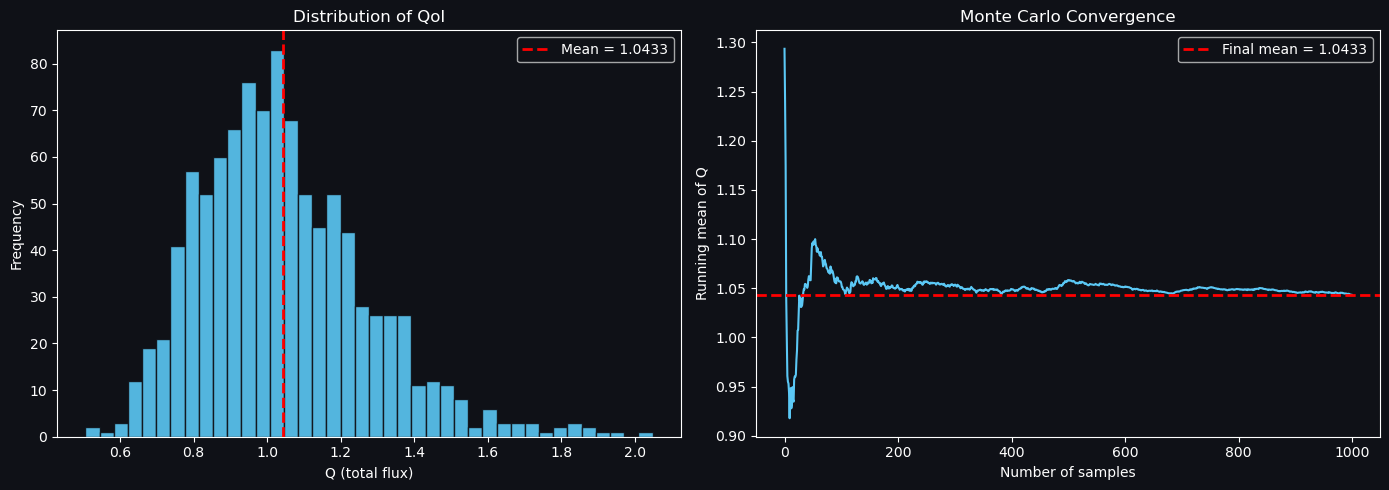

In [114]:
analyze_qoi(Q_samples_fine_normalized)

In [116]:
from networkx.algorithms.community import greedy_modularity_communities, modularity

communities = list(greedy_modularity_communities(G_nx))
mod_score = modularity(G_nx, communities)

print(f"Modularity: {mod_score:.4f}")
print(f"Number of communities: {len(communities)}")
print(f"Sizes: {sorted([len(c) for c in communities], reverse=True)}")

Modularity: 0.0912
Number of communities: 2
Sizes: [47, 44]


In [118]:
node_to_comm = {v: i for i, c in enumerate(communities) for v in c}
within = sum(1 for u, v in G_nx.edges() if node_to_comm[u] == node_to_comm[v])
between = G_nx.number_of_edges() - within
print(f"Within-community edges: {within} ({within/G_nx.number_of_edges()*100:.1f}%)")
print(f"Between-community edges: {between} ({between/G_nx.number_of_edges()*100:.1f}%)")

Within-community edges: 345 (59.3%)
Between-community edges: 237 (40.7%)


In [124]:
def build_capped_aggregation_respecting_boundary(G_nx, gamma_in, gamma_out, max_size=4):
    gamma_in_set = set(gamma_in)
    gamma_out_set = set(gamma_out)

    def forbidden_pair(a, b):
        return (a in gamma_in_set and b in gamma_out_set) or \
               (a in gamma_out_set and b in gamma_in_set)

    aggregate_of = {}
    agg_sizes = {}
    agg_has_gamma_in = {}
    agg_has_gamma_out = {}
    next_agg_id = 0

    nodes_by_degree = sorted(G_nx.nodes(), key=lambda v: G_nx.degree(v))

    for v in nodes_by_degree:
        if v in aggregate_of:
            continue

        partner = None
        for neighbor in G_nx.neighbors(v):
            if neighbor not in aggregate_of and not forbidden_pair(v, neighbor):
                partner = neighbor
                break

        if partner is not None:
            aggregate_of[v] = next_agg_id
            aggregate_of[partner] = next_agg_id
            agg_sizes[next_agg_id] = 2
            agg_has_gamma_in[next_agg_id] = (v in gamma_in_set) or (partner in gamma_in_set)
            agg_has_gamma_out[next_agg_id] = (v in gamma_out_set) or (partner in gamma_out_set)
            next_agg_id += 1
        else:
            joined = False
            for neighbor in G_nx.neighbors(v):
                if neighbor in aggregate_of and not forbidden_pair(v, neighbor):
                    agg_id = aggregate_of[neighbor]
                    v_is_in = v in gamma_in_set
                    v_is_out = v in gamma_out_set
                    # also block joining if it would introduce the opposite boundary type
                    if (v_is_in and agg_has_gamma_out.get(agg_id, False)) or \
                       (v_is_out and agg_has_gamma_in.get(agg_id, False)):
                        continue
                    if agg_sizes[agg_id] < max_size:
                        aggregate_of[v] = agg_id
                        agg_sizes[agg_id] += 1
                        agg_has_gamma_in[agg_id] = agg_has_gamma_in.get(agg_id, False) or v_is_in
                        agg_has_gamma_out[agg_id] = agg_has_gamma_out.get(agg_id, False) or v_is_out
                        joined = True
                        break
            if not joined:
                aggregate_of[v] = next_agg_id
                agg_sizes[next_agg_id] = 1
                agg_has_gamma_in[next_agg_id] = v in gamma_in_set
                agg_has_gamma_out[next_agg_id] = v in gamma_out_set
                next_agg_id += 1

    unique_ids = sorted(set(aggregate_of.values()))
    relabel = {old: new for new, old in enumerate(unique_ids)}
    aggregate_of = {v: relabel[a] for v, a in aggregate_of.items()}
    return aggregate_of, len(unique_ids)

aggregate_of, n_coarse = build_capped_aggregation_respecting_boundary(G_nx, gamma_in, gamma_out, max_size=4)
print(f"n_coarse: {n_coarse}")

groups = {}
for v, a in aggregate_of.items():
    groups.setdefault(a, []).append(v)
sizes = [len(m) for m in groups.values()]
print(f"Sizes: {sorted(sizes, reverse=True)}")

gamma_in_coarse = sorted(set(aggregate_of[v] for v in gamma_in))
gamma_out_coarse = sorted(set(aggregate_of[v] for v in gamma_out))
overlap = set(gamma_in_coarse) & set(gamma_out_coarse)
print(f"Overlap (should be empty): {overlap}")

n_coarse: 58
Sizes: [4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Overlap (should be empty): set()


In [126]:
aggregate_of, n_coarse = build_capped_aggregation_respecting_boundary(G_nx, gamma_in, gamma_out, max_size=8)
print(f"n_coarse: {n_coarse}")

groups = {}
for v, a in aggregate_of.items():
    groups.setdefault(a, []).append(v)
sizes = [len(m) for m in groups.values()]
print(f"Sizes: {sorted(sizes, reverse=True)}")
print(f"Singletons: {sizes.count(1)}")

gamma_in_coarse = sorted(set(aggregate_of[v] for v in gamma_in))
gamma_out_coarse = sorted(set(aggregate_of[v] for v in gamma_out))
overlap = set(gamma_in_coarse) & set(gamma_out_coarse)
print(f"Overlap: {overlap}")

n_coarse: 23
Sizes: [8, 8, 8, 8, 8, 8, 8, 8, 6, 5, 4, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Singletons: 12
Overlap: set()


In [128]:
coarse_edges, coarse_contribs = build_coarse_graph_edges(edges, aggregate_of)
print(f"coarse edges: {len(coarse_edges)}")

coarse edges: 84


In [130]:
gamma_in_coarse = sorted(set(aggregate_of[v] for v in gamma_in))
gamma_out_coarse = sorted(set(aggregate_of[v] for v in gamma_out))
print(f"gamma_in_coarse: {gamma_in_coarse}")
print(f"gamma_out_coarse: {gamma_out_coarse}")

gamma_in_coarse: [12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]
gamma_out_coarse: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]


In [132]:
# ==================== Coarse graph setup ====================

coarse_edges_arr = np.array(coarse_edges)
i_arr_c = coarse_edges_arr[:, 0]
j_arr_c = coarse_edges_arr[:, 1]
row_idx_c = np.concatenate([i_arr_c, j_arr_c, i_arr_c, j_arr_c])
col_idx_c = np.concatenate([i_arr_c, j_arr_c, j_arr_c, i_arr_c])

gamma_in_coarse_set = set(gamma_in_coarse)
gamma_out_coarse_set = set(gamma_out_coarse)

boundary_coarse = set(gamma_in_coarse) | set(gamma_out_coarse)
interior_coarse = np.array([v for v in range(n_coarse) if v not in boundary_coarse])

p_known_coarse = np.full(n_coarse, np.nan)
for v in gamma_in_coarse:
    p_known_coarse[v] = 1.0
for v in gamma_out_coarse:
    p_known_coarse[v] = 0.0

print(f"n_coarse: {n_coarse}")
print(f"boundary_coarse size: {len(boundary_coarse)}")
print(f"interior_coarse size: {len(interior_coarse)}")


# ==================== One paired fine/coarse sample ====================

def run_one_paired_sample(seed):
    rng = np.random.RandomState(seed)
    w = rng.randn(len(edges))

    # ---- FINE pipeline ----
    f = B @ w
    u = factor.solve_A(np.sqrt(lambda_min) * f)
    k_vals = np.exp((u[i_arr] + u[j_arr]) / 2)

    diag_data = np.concatenate([k_vals, k_vals])
    offdiag_data = np.concatenate([-k_vals, -k_vals])
    data = np.concatenate([diag_data, offdiag_data])
    L_k = coo_matrix((data, (row_idx, col_idx)), shape=(n_vertices, n_vertices)).tocsr()

    L_interior = L_k[interior, :][:, interior]
    rhs = -L_k[interior, :][:, list(boundary)] @ p_known[list(boundary)]
    p_interior = spsolve(L_interior, rhs)

    p = np.zeros(n_vertices)
    p[interior] = p_interior
    for v in gamma_in:
        p[v] = 1.0
    for v in gamma_out:
        p[v] = 0.0

    p_diff = np.abs(p[i_arr] - p[j_arr])
    outlet_mask = np.array([i in gamma_out_set or j in gamma_out_set for i, j in edges])
    Q_fine = np.sum(k_vals[outlet_mask] * p_diff[outlet_mask])

    # ---- COARSE pipeline — permeability derived from the SAME k_vals ----
    coarse_k_vals = np.array([sum(k_vals[idx] for idx in coarse_contribs[e]) for e in coarse_edges])

    diag_c = np.concatenate([coarse_k_vals, coarse_k_vals])
    offdiag_c = np.concatenate([-coarse_k_vals, -coarse_k_vals])
    data_c = np.concatenate([diag_c, offdiag_c])
    L_k_c = coo_matrix((data_c, (row_idx_c, col_idx_c)), shape=(n_coarse, n_coarse)).tocsr()

    L_interior_c = L_k_c[interior_coarse, :][:, interior_coarse]
    rhs_c = -L_k_c[interior_coarse, :][:, list(boundary_coarse)] @ p_known_coarse[list(boundary_coarse)]
    p_interior_c = spsolve(L_interior_c, rhs_c)

    p_c = np.zeros(n_coarse)
    p_c[interior_coarse] = p_interior_c
    for v in gamma_in_coarse:
        p_c[v] = 1.0
    for v in gamma_out_coarse:
        p_c[v] = 0.0

    p_diff_c = np.abs(p_c[i_arr_c] - p_c[j_arr_c])
    outlet_mask_c = np.array([i in gamma_out_coarse_set or j in gamma_out_coarse_set for i, j in coarse_edges])
    Q_coarse = np.sum(coarse_k_vals[outlet_mask_c] * p_diff_c[outlet_mask_c])

    return Q_fine, Q_coarse


# ==================== Run N paired samples ====================

N = 300
Q_fine_samples = np.zeros(N)
Q_coarse_samples = np.zeros(N)

for n in range(N):
    qf, qc = run_one_paired_sample(seed=n)
    Q_fine_samples[n] = qf
    Q_coarse_samples[n] = qc

diff_samples = Q_fine_samples - Q_coarse_samples
correlation = np.corrcoef(Q_fine_samples, Q_coarse_samples)[0, 1]

print(f"\nN = {N} paired samples\n")
print(f"Q_fine   : mean={Q_fine_samples.mean():.4f}  var={Q_fine_samples.var():.4f}")
print(f"Q_coarse : mean={Q_coarse_samples.mean():.4f}  var={Q_coarse_samples.var():.4f}")
print(f"Q_fine - Q_coarse : mean={diff_samples.mean():.4f}  var={diff_samples.var():.4f}")
print(f"\nCorrelation(Q_fine, Q_coarse): {correlation:.4f}")
print(f"Variance reduction (var(Q_fine)/var(diff)): {Q_fine_samples.var()/diff_samples.var():.2f}x")

n_coarse: 23
boundary_coarse size: 23
interior_coarse size: 0


IndexError: arrays used as indices must be of integer (or boolean) type

In [134]:
print(interior_coarse)
print(interior_coarse.dtype)
print(len(interior_coarse))

[]
float64
0


In [136]:
print(f"gamma_in size: {len(gamma_in)}, gamma_out size: {len(gamma_out)}")
print(f"gamma_in_coarse size: {len(gamma_in_coarse)}, gamma_out_coarse size: {len(gamma_out_coarse)}")
print(f"n_coarse: {n_coarse}")

# how many coarse vertices come ONLY from interior fine vertices?
boundary_fine_set = set(gamma_in) | set(gamma_out)
interior_fine = [v for v in range(n_vertices) if v not in boundary_fine_set]
interior_coarse_ids = set(aggregate_of[v] for v in interior_fine)
print(f"Coarse aggregates containing at least one interior fine vertex: {len(interior_coarse_ids)}")
print(f"Coarse aggregates that are PURELY boundary (no interior fine vertex at all): {n_coarse - len(interior_coarse_ids)}")

gamma_in size: 11, gamma_out size: 12
gamma_in_coarse size: 11, gamma_out_coarse size: 12
n_coarse: 23
Coarse aggregates containing at least one interior fine vertex: 11
Coarse aggregates that are PURELY boundary (no interior fine vertex at all): 12


In [138]:
aggregate_of, n_coarse = build_capped_aggregation_v2(G_nx, gamma_in, gamma_out, max_size=8)

groups = {}
for v, a in aggregate_of.items():
    groups.setdefault(a, []).append(v)
sizes = [len(m) for m in groups.values()]
print(f"n_coarse: {n_coarse}")
print(f"Sizes: {sorted(sizes, reverse=True)}")

gamma_in_coarse = sorted(set(aggregate_of[v] for v in gamma_in))
gamma_out_coarse = sorted(set(aggregate_of[v] for v in gamma_out))
overlap = set(gamma_in_coarse) & set(gamma_out_coarse)
print(f"gamma_in_coarse: {len(gamma_in_coarse)}, gamma_out_coarse: {len(gamma_out_coarse)}")
print(f"Overlap: {overlap}")

boundary_coarse_new = set(gamma_in_coarse) | set(gamma_out_coarse)
interior_coarse_new = [v for v in range(n_coarse) if v not in boundary_coarse_new]
print(f"Interior coarse vertices: {len(interior_coarse_new)}")

NameError: name 'build_capped_aggregation_v2' is not defined